In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================
# LOAD PREPROCESSED DATA
# ============================================================
print("="*60)
print("LOADING PREPROCESSED DATA")
print("="*60)

batsman_df = pd.read_csv('/kaggle/input/cricket-ds-final/batsman_match_stats.csv')
bowler_df = pd.read_csv('/kaggle/input/cricket-ds-final/bowler_match_stats.csv')

batsman_df['date'] = pd.to_datetime(batsman_df['date'])
bowler_df['date'] = pd.to_datetime(bowler_df['date'])

batsman_df['strike_rate'] = batsman_df['strike_rate'].replace([np.inf, -np.inf], np.nan)
bowler_df['economy'] = bowler_df['economy'].replace([np.inf, -np.inf], np.nan)

print(f"✅ Batsman data: {batsman_df.shape}")
print(f"✅ Bowler data: {bowler_df.shape}")


LOADING PREPROCESSED DATA
✅ Batsman data: (14805, 20)
✅ Bowler data: (11542, 20)



1. TARGET VARIABLE DISTRIBUTION


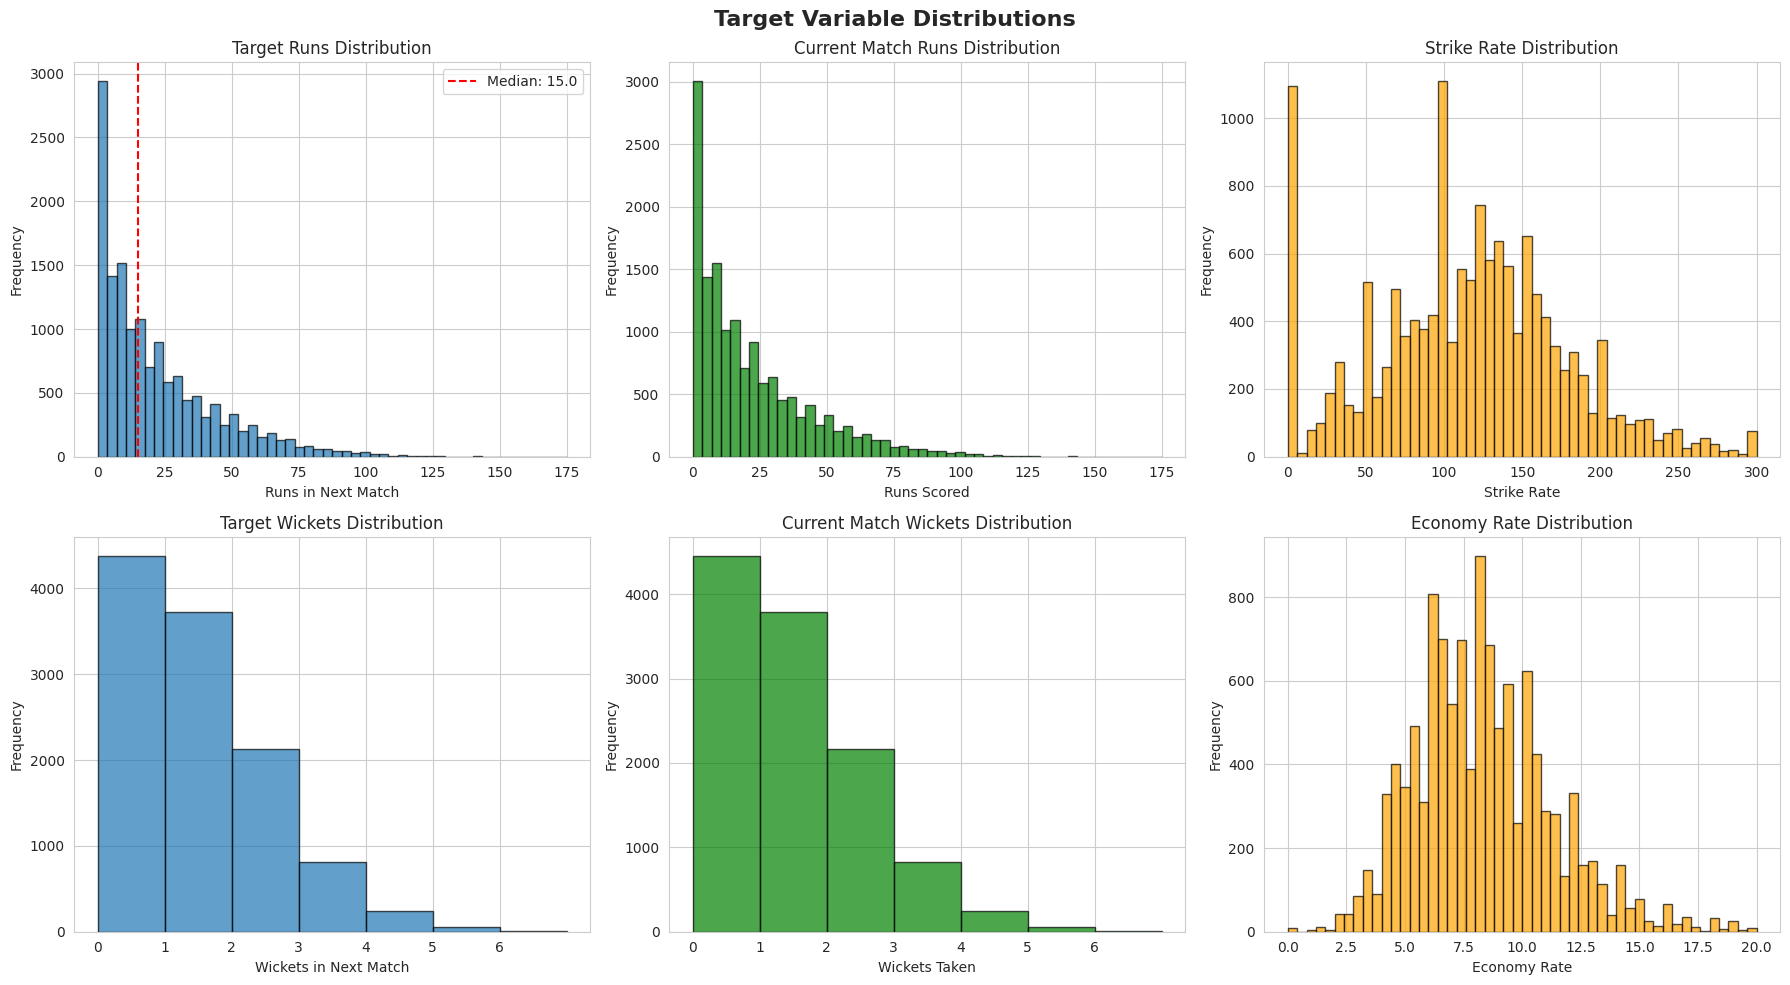


📊 Batsman Target Stats:
count    14579.000000
mean        22.052679
std         22.179981
min          0.000000
25%          5.000000
50%         15.000000
75%         33.000000
max        175.000000
Name: target_runs, dtype: float64

📊 Bowler Target Stats:
count    11352.000000
mean         1.030303
std          1.065537
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: target_wickets, dtype: float64


In [2]:
# ============================================================
# 1. TARGET VARIABLE DISTRIBUTION ANALYSIS
# ============================================================
print("\n" + "="*60)
print("1. TARGET VARIABLE DISTRIBUTION")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Target Variable Distributions', fontsize=16, fontweight='bold')

axes[0, 0].hist(batsman_df['target_runs'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Target Runs Distribution')
axes[0, 0].set_xlabel('Runs in Next Match')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(batsman_df['target_runs'].median(), color='red', linestyle='--', 
                    label=f'Median: {batsman_df["target_runs"].median():.1f}')
axes[0, 0].legend()

axes[0, 1].hist(batsman_df['runs'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Current Match Runs Distribution')
axes[0, 1].set_xlabel('Runs Scored')
axes[0, 1].set_ylabel('Frequency')

strike_rate_clean = batsman_df['strike_rate'].dropna()
strike_rate_clean = strike_rate_clean[strike_rate_clean <= 300]
axes[0, 2].hist(strike_rate_clean, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].set_title('Strike Rate Distribution')
axes[0, 2].set_xlabel('Strike Rate')
axes[0, 2].set_ylabel('Frequency')

axes[1, 0].hist(bowler_df['target_wickets'].dropna(), bins=range(0, 8), edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Target Wickets Distribution')
axes[1, 0].set_xlabel('Wickets in Next Match')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xticks(range(0, 7))

axes[1, 1].hist(bowler_df['wickets'], bins=range(0, 8), edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title('Current Match Wickets Distribution')
axes[1, 1].set_xlabel('Wickets Taken')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xticks(range(0, 7))

economy_clean = bowler_df['economy'].dropna()
economy_clean = economy_clean[economy_clean <= 20]
axes[1, 2].hist(economy_clean, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 2].set_title('Economy Rate Distribution')
axes[1, 2].set_xlabel('Economy Rate')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('01_target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Batsman Target Stats:")
print(batsman_df['target_runs'].describe())
print(f"\n📊 Bowler Target Stats:")
print(bowler_df['target_wickets'].describe())



2. VENUE ANALYSIS

Top 10 Venues by Matches Played:
venue
Eden Gardens                                 994
Wankhede Stadium                             957
M Chinnaswamy Stadium                        794
Feroz Shah Kotla                             767
Wankhede Stadium, Mumbai                     651
Rajiv Gandhi International Stadium, Uppal    616
Dubai International Cricket Stadium          611
MA Chidambaram Stadium, Chepauk              599
Sawai Mansingh Stadium                       564
MA Chidambaram Stadium, Chepauk, Chennai     457
Name: count, dtype: int64


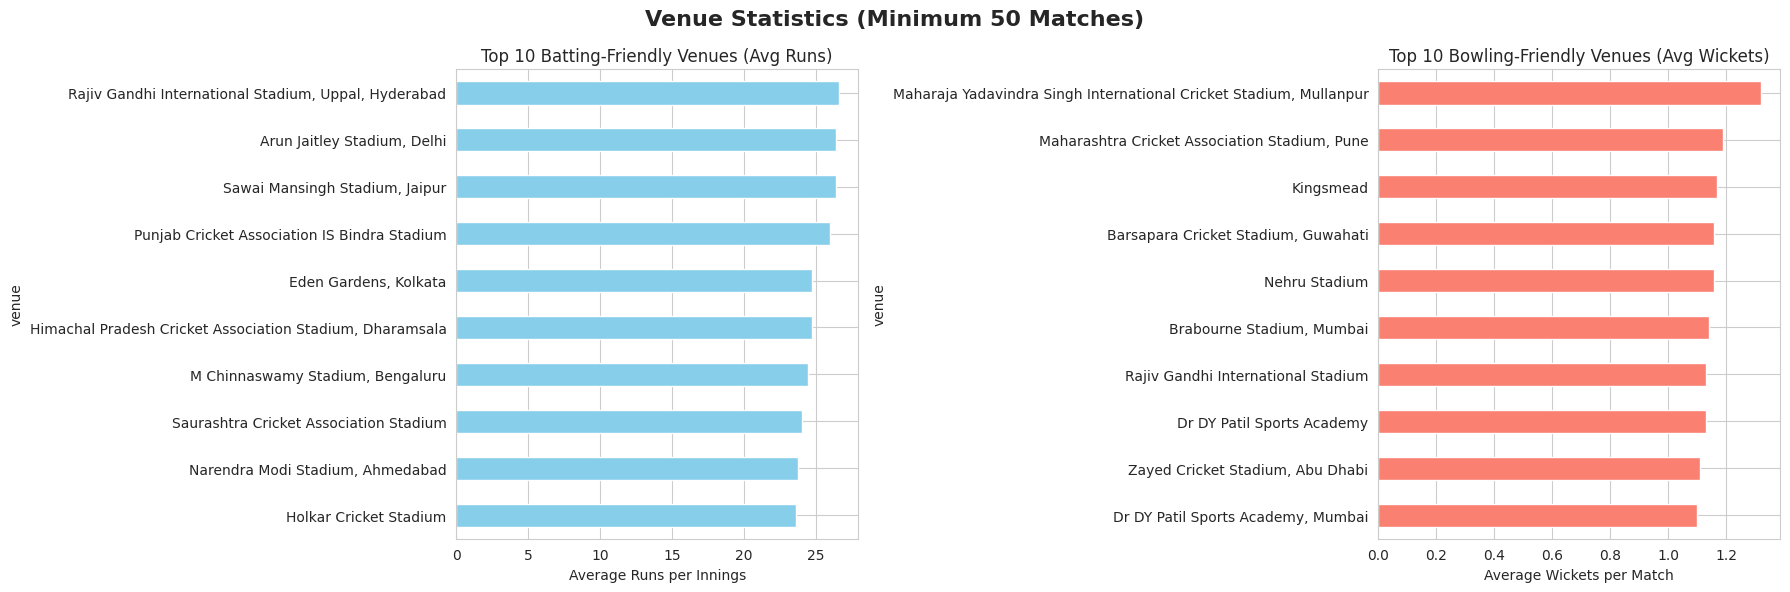


📊 Top Batting Venues:
                                                    avg_runs  matches  \
venue                                                                   
Rajiv Gandhi International Stadium, Uppal, Hyde...     26.58      223   
Arun Jaitley Stadium, Delhi                            26.38      277   
Sawai Mansingh Stadium, Jaipur                         26.35      191   
Punjab Cricket Association IS Bindra Stadium           25.96      126   
Eden Gardens, Kolkata                                  24.73      283   
Himachal Pradesh Cricket Association Stadium, D...     24.69       70   
M Chinnaswamy Stadium, Bengaluru                       24.45      244   
Saurashtra Cricket Association Stadium                 24.02      126   
Narendra Modi Stadium, Ahmedabad                       23.75      421   
Holkar Cricket Stadium                                 23.62      105   

                                                    avg_strike_rate  
venue                         

In [3]:
# ============================================================
# 2. VENUE ANALYSIS
# ============================================================
print("\n" + "="*60)
print("2. VENUE ANALYSIS")
print("="*60)

top_venues = batsman_df['venue'].value_counts().head(10)
print(f"\nTop 10 Venues by Matches Played:")
print(top_venues)

venue_batting_stats = batsman_df.groupby('venue').agg({
    'runs': ['mean', 'count'],
    'strike_rate': 'mean'
}).round(2)
venue_batting_stats.columns = ['avg_runs', 'matches', 'avg_strike_rate']
venue_batting_stats = venue_batting_stats[venue_batting_stats['matches'] >= 50].sort_values('avg_runs', ascending=False)

venue_bowling_stats = bowler_df.groupby('venue').agg({
    'wickets': ['mean', 'count'],
    'economy': 'mean'
}).round(2)
venue_bowling_stats.columns = ['avg_wickets', 'matches', 'avg_economy']
venue_bowling_stats = venue_bowling_stats[venue_bowling_stats['matches'] >= 50].sort_values('avg_wickets', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Venue Statistics (Minimum 50 Matches)', fontsize=16, fontweight='bold')

venue_batting_stats.head(10)['avg_runs'].plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Batting-Friendly Venues (Avg Runs)')
axes[0].set_xlabel('Average Runs per Innings')
axes[0].invert_yaxis()

venue_bowling_stats.head(10)['avg_wickets'].plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Top 10 Bowling-Friendly Venues (Avg Wickets)')
axes[1].set_xlabel('Average Wickets per Match')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('02_venue_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Top Batting Venues:")
print(venue_batting_stats.head(10))



3. OPPONENT STRENGTH ANALYSIS


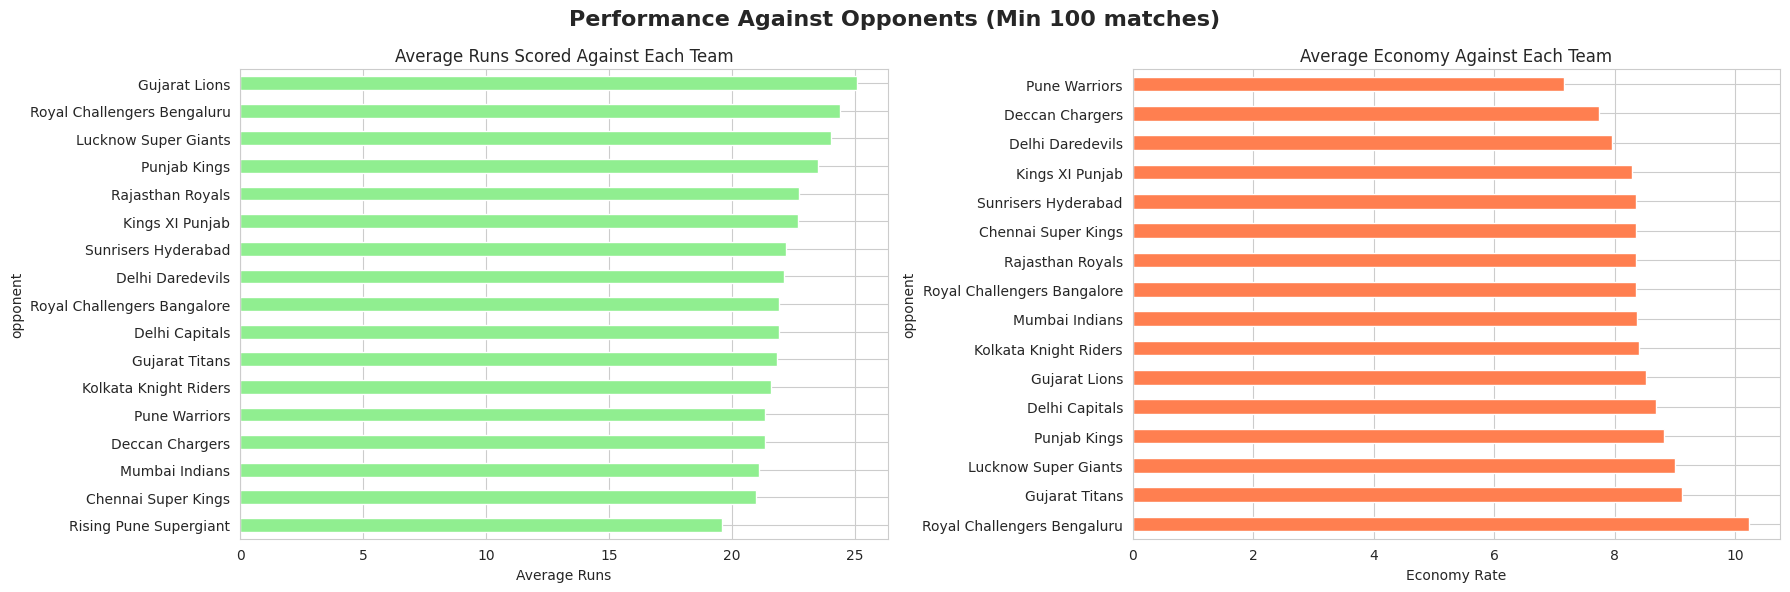


📊 Performance Against Teams:
                             avg_runs  innings
opponent                                      
Gujarat Lions                   25.07      182
Royal Challengers Bengaluru     24.40      182
Lucknow Super Giants            24.02      350
Punjab Kings                    23.49      462
Rajasthan Royals                22.72     1467
Kings XI Punjab                 22.67     1183
Sunrisers Hyderabad             22.18     1277
Delhi Daredevils                22.13      952
Royal Challengers Bangalore     21.92     1520
Delhi Capitals                  21.90      715
Gujarat Titans                  21.85      378
Kolkata Knight Riders           21.59     1675
Pune Warriors                   21.36      286
Deccan Chargers                 21.35      453
Mumbai Indians                  21.09     1799
Chennai Super Kings             20.97     1644
Rising Pune Supergiant          19.61      111


In [4]:
# ============================================================
# 3. OPPONENT STRENGTH ANALYSIS
# ============================================================
print("\n" + "="*60)
print("3. OPPONENT STRENGTH ANALYSIS")
print("="*60)

opponent_batting = batsman_df.groupby('opponent').agg({
    'runs': ['mean', 'count']
}).round(2)
opponent_batting.columns = ['avg_runs', 'innings']
opponent_batting = opponent_batting[opponent_batting['innings'] >= 100].sort_values('avg_runs', ascending=False)

opponent_bowling = bowler_df.groupby('opponent').agg({
    'wickets': ['mean', 'count'],
    'economy': 'mean'
}).round(2)
opponent_bowling.columns = ['avg_wickets', 'matches', 'avg_economy']
opponent_bowling = opponent_bowling[opponent_bowling['matches'] >= 100].sort_values('avg_economy')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Performance Against Opponents (Min 100 matches)', fontsize=16, fontweight='bold')

opponent_batting['avg_runs'].plot(kind='barh', ax=axes[0], color='lightgreen')
axes[0].set_title('Average Runs Scored Against Each Team')
axes[0].set_xlabel('Average Runs')
axes[0].invert_yaxis()

opponent_bowling['avg_economy'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Average Economy Against Each Team')
axes[1].set_xlabel('Economy Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('03_opponent_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Performance Against Teams:")
print(opponent_batting)


4. TEMPORAL TRENDS


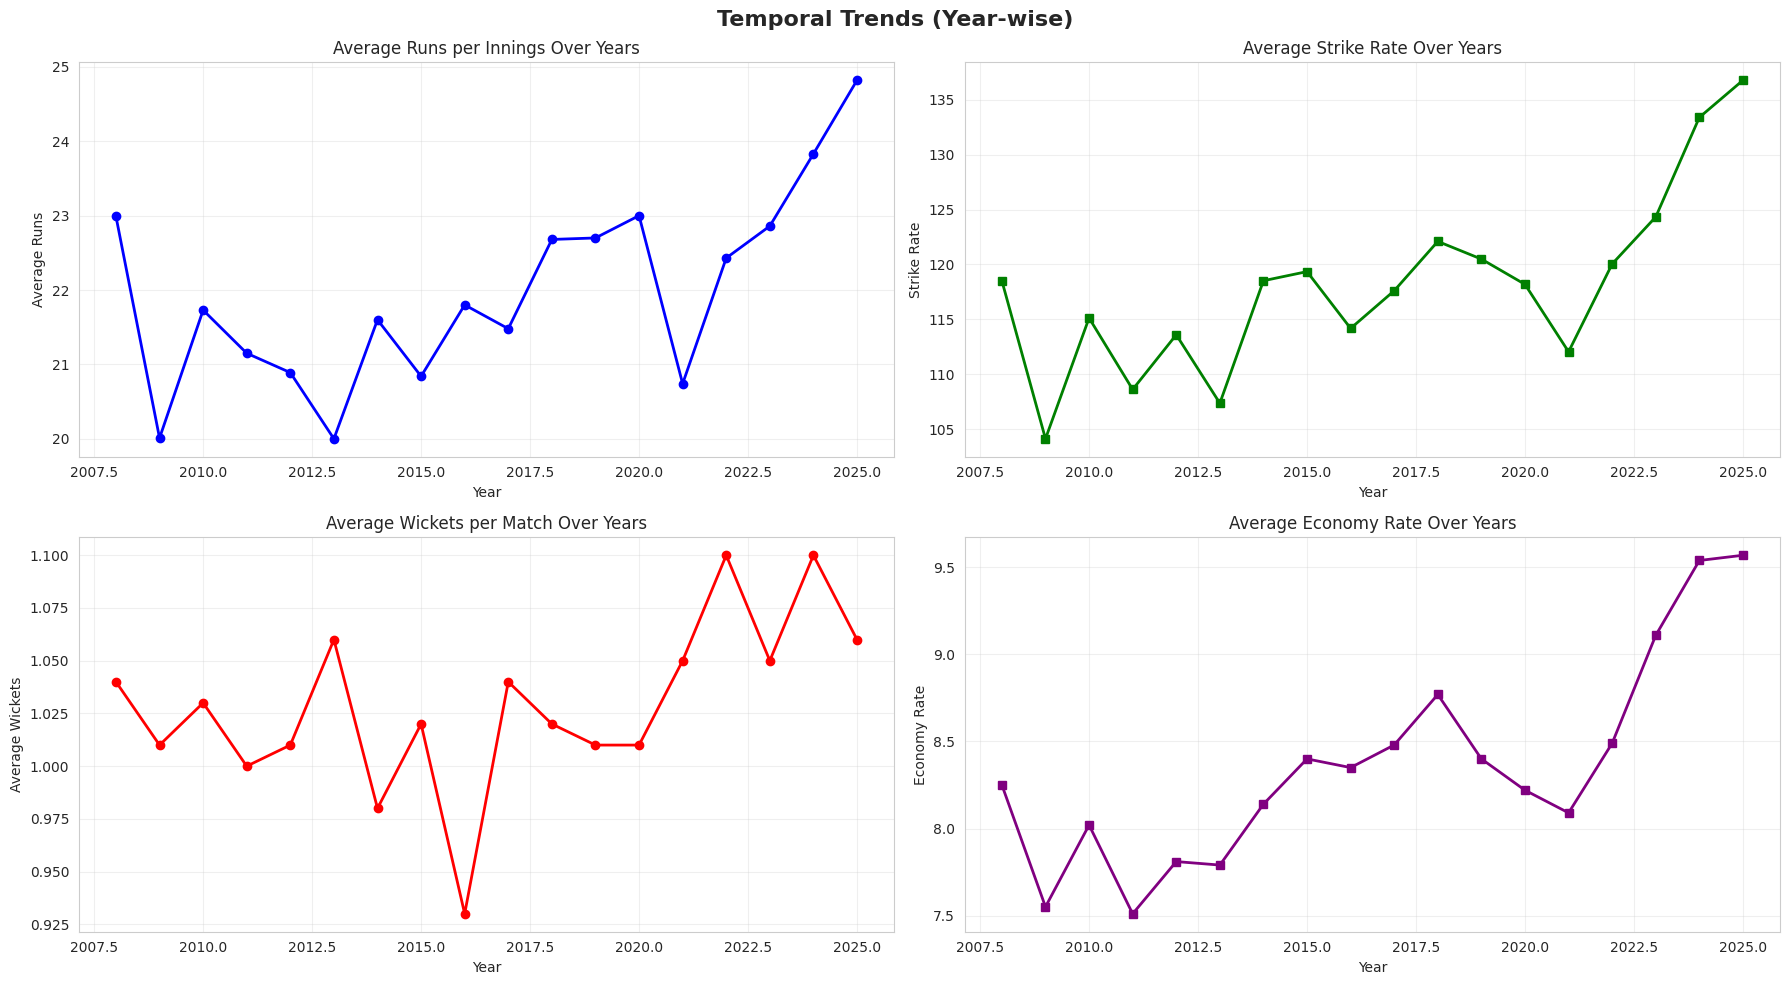

In [5]:
# ============================================================
# 4. TEMPORAL TRENDS
# ============================================================
print("\n" + "="*60)
print("4. TEMPORAL TRENDS")
print("="*60)

batsman_df['year'] = batsman_df['date'].dt.year
bowler_df['year'] = bowler_df['date'].dt.year

yearly_batting = batsman_df.groupby('year').agg({
    'runs': 'mean',
    'strike_rate': 'mean',
    'boundaries': 'mean'
}).round(2)

yearly_bowling = bowler_df.groupby('year').agg({
    'wickets': 'mean',
    'economy': 'mean'
}).round(2)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Temporal Trends (Year-wise)', fontsize=16, fontweight='bold')

axes[0, 0].plot(yearly_batting.index, yearly_batting['runs'], marker='o', linewidth=2, color='blue')
axes[0, 0].set_title('Average Runs per Innings Over Years')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Average Runs')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(yearly_batting.index, yearly_batting['strike_rate'], marker='s', linewidth=2, color='green')
axes[0, 1].set_title('Average Strike Rate Over Years')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Strike Rate')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(yearly_bowling.index, yearly_bowling['wickets'], marker='o', linewidth=2, color='red')
axes[1, 0].set_title('Average Wickets per Match Over Years')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Wickets')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(yearly_bowling.index, yearly_bowling['economy'], marker='s', linewidth=2, color='purple')
axes[1, 1].set_title('Average Economy Rate Over Years')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Economy Rate')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()


5. TOP PERFORMERS


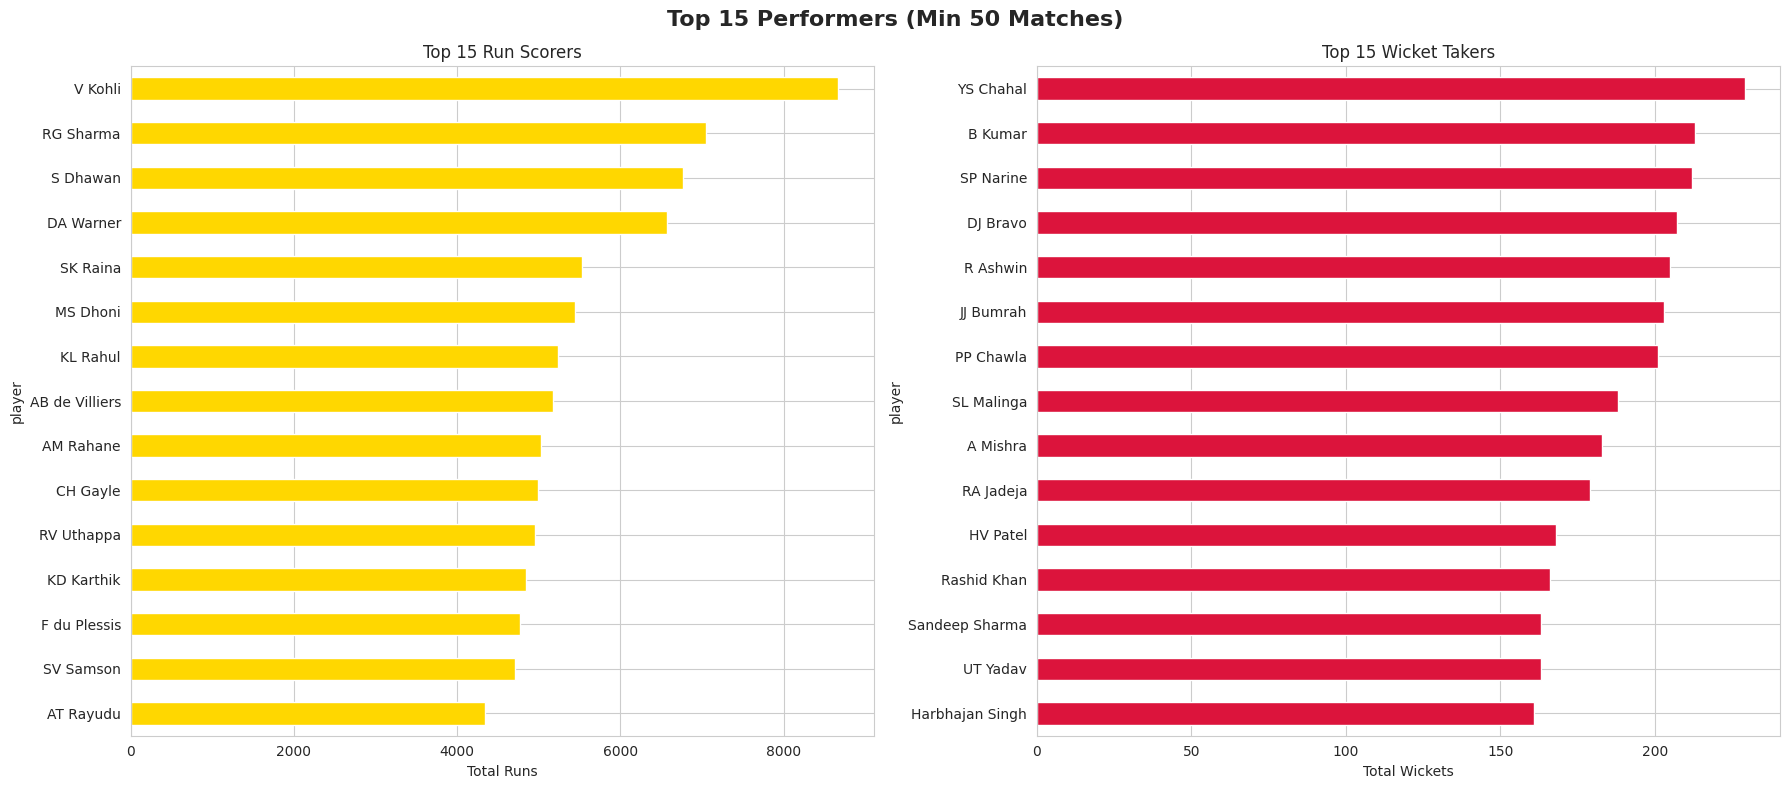


🏆 Top 10 Batsmen:
                total_runs  avg_runs  matches
player                                       
V Kohli               8671     33.35      260
RG Sharma             7048     26.40      267
S Dhawan              6769     30.63      221
DA Warner             6567     35.69      184
SK Raina              5536     27.68      200
MS Dhoni              5439     22.57      241
KL Rahul              5235     38.78      135
AB de Villiers        5181     30.48      170
AM Rahane             5032     27.50      183
CH Gayle              4997     35.44      141

🏆 Top 10 Bowlers:
            total_wickets  avg_wickets  matches
player                                         
YS Chahal             229         1.33      172
B Kumar               213         1.12      190
SP Narine             212         1.13      187
DJ Bravo              207         1.31      158
R Ashwin              205         0.94      218
JJ Bumrah             203         1.40      145
PP Chawla             201 

In [6]:
# ============================================================
# 5. TOP PERFORMERS
# ============================================================
print("\n" + "="*60)
print("5. TOP PERFORMERS")
print("="*60)

top_batsmen = batsman_df.groupby('player')['runs'].agg(['sum', 'mean', 'count']).round(2)
top_batsmen.columns = ['total_runs', 'avg_runs', 'matches']
top_batsmen = top_batsmen[top_batsmen['matches'] >= 50].sort_values('total_runs', ascending=False).head(15)

top_bowlers = bowler_df.groupby('player')['wickets'].agg(['sum', 'mean', 'count']).round(2)
top_bowlers.columns = ['total_wickets', 'avg_wickets', 'matches']
top_bowlers = top_bowlers[top_bowlers['matches'] >= 50].sort_values('total_wickets', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top 15 Performers (Min 50 Matches)', fontsize=16, fontweight='bold')

top_batsmen['total_runs'].plot(kind='barh', ax=axes[0], color='gold')
axes[0].set_title('Top 15 Run Scorers')
axes[0].set_xlabel('Total Runs')
axes[0].invert_yaxis()

top_bowlers['total_wickets'].plot(kind='barh', ax=axes[1], color='crimson')
axes[1].set_title('Top 15 Wicket Takers')
axes[1].set_xlabel('Total Wickets')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('05_top_performers.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🏆 Top 10 Batsmen:")
print(top_batsmen.head(10))
print(f"\n🏆 Top 10 Bowlers:")
print(top_bowlers.head(10))



6. CORRELATION ANALYSIS


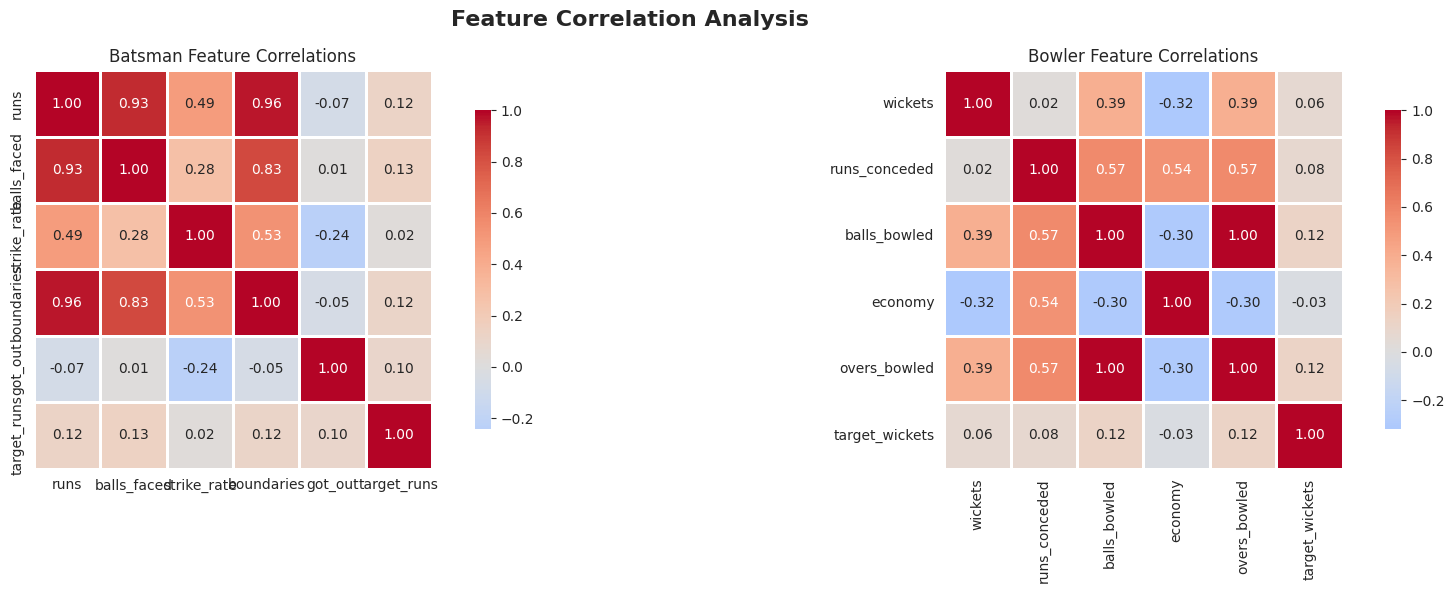


📊 Batsman Correlations with Target Runs:
target_runs    1.000000
balls_faced    0.132989
runs           0.118123
boundaries     0.116695
got_out        0.095052
strike_rate    0.022059
Name: target_runs, dtype: float64

📊 Bowler Correlations with Target Wickets:
target_wickets    1.000000
balls_bowled      0.122950
overs_bowled      0.122950
runs_conceded     0.076129
wickets           0.064771
economy          -0.028804
Name: target_wickets, dtype: float64


In [7]:
# ============================================================
# 6. CORRELATION ANALYSIS
# ============================================================
print("\n" + "="*60)
print("6. CORRELATION ANALYSIS")
print("="*60)

batsman_corr_cols = ['runs', 'balls_faced', 'strike_rate', 'boundaries', 'got_out', 'target_runs']
batsman_corr = batsman_df[batsman_corr_cols].corr()

bowler_corr_cols = ['wickets', 'runs_conceded', 'balls_bowled', 'economy', 'overs_bowled', 'target_wickets']
bowler_corr = bowler_df[bowler_corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Correlation Analysis', fontsize=16, fontweight='bold')

sns.heatmap(batsman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
axes[0].set_title('Batsman Feature Correlations')

sns.heatmap(bowler_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1],
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
axes[1].set_title('Bowler Feature Correlations')

plt.tight_layout()
plt.savefig('06_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Batsman Correlations with Target Runs:")
print(batsman_corr['target_runs'].sort_values(ascending=False))
print(f"\n📊 Bowler Correlations with Target Wickets:")
print(bowler_corr['target_wickets'].sort_values(ascending=False))



7. RECENT FORM ANALYSIS (LAST 5 vs LAST 10 MATCHES)

🔥 BATSMAN FORM ANALYSIS:

Top 10 In-Form Batsmen (Recent 5 > Career):
                player  career_avg  last_5_avg  form_indicator
122           MR Marsh   26.367347        56.6       30.232653
177           SA Yadav   28.549669        48.4       19.850331
1             A Badoni   20.934783        39.6       18.665217
69        Ishan Kishan   26.530973        43.0       16.469027
18     Abhishek Sharma   24.540541        39.8       15.259459
219  Washington Sundar   11.883721        26.6       14.716279
21       Azhar Mahmood   18.476190        33.0       14.523810
6         AC Gilchrist   25.862500        40.0       14.137500
166         RR Rossouw   21.500000        35.0       13.500000
80           JM Sharma   21.085106        32.0       10.914894

Top 10 Out-of-Form Batsmen (Recent 5 < Career):
            player  career_avg  last_5_avg  form_indicator
168     RV Uthappa   25.147208         6.6      -18.547208
145      Q de Ko

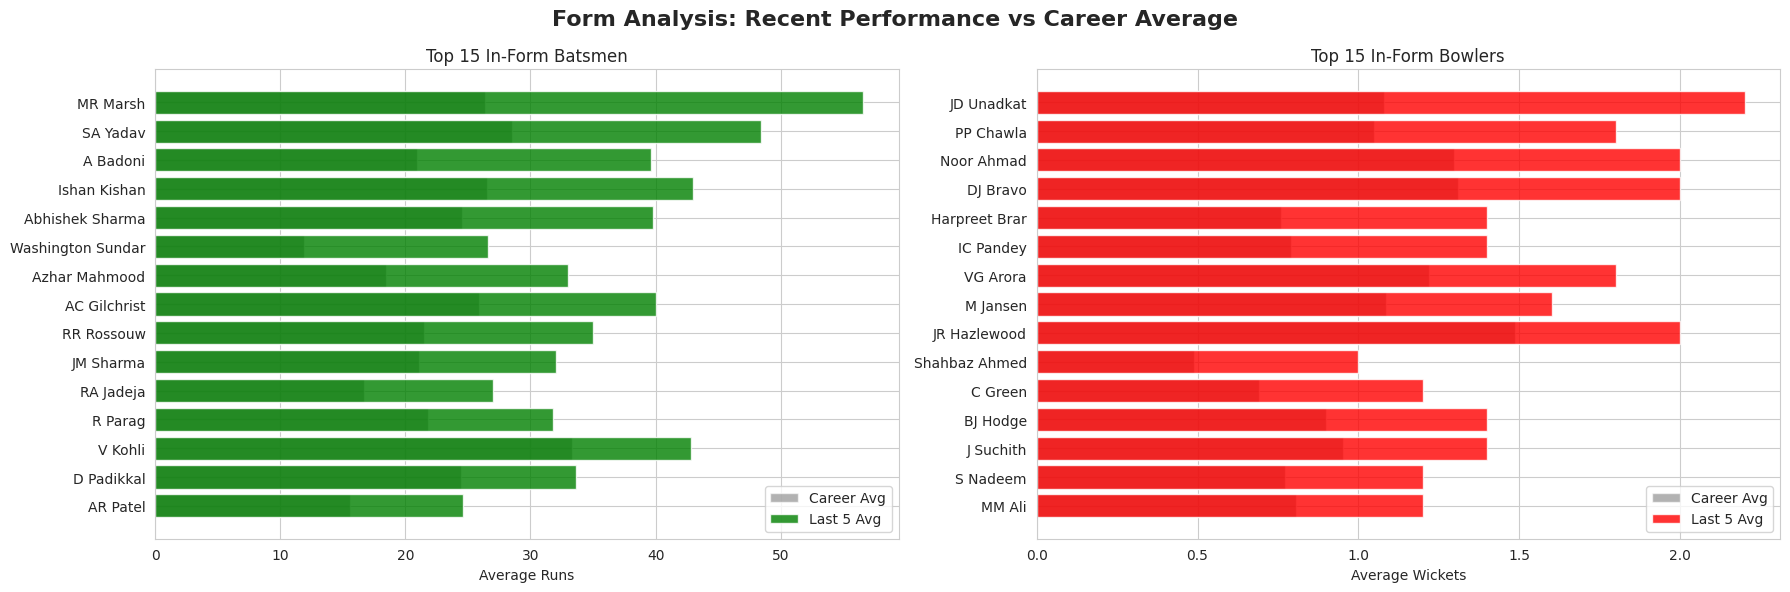

In [8]:
# ============================================================
# SECTION 7: RECENT FORM ANALYSIS ***
# ============================================================
print("\n" + "="*60)
print("7. RECENT FORM ANALYSIS (LAST 5 vs LAST 10 MATCHES)")
print("="*60)

# Function to calculate recent form
def calculate_recent_form(df, player_col, stat_col, windows=[5, 10]):
    results = []
    
    for player in df[player_col].unique():
        player_data = df[df[player_col] == player].sort_values('date')
        
        if len(player_data) >= 20:  # Only players with 20+ matches
            career_avg = player_data[stat_col].mean()
            recent_5 = player_data.tail(5)[stat_col].mean()
            recent_10 = player_data.tail(10)[stat_col].mean()
            
            results.append({
                'player': player,
                'career_avg': career_avg,
                'last_5_avg': recent_5,
                'last_10_avg': recent_10,
                'total_matches': len(player_data),
                'form_indicator': recent_5 - career_avg  # Positive = In form
            })
    
    return pd.DataFrame(results)

print("\n🔥 BATSMAN FORM ANALYSIS:")
batsman_form = calculate_recent_form(batsman_df, 'player', 'runs')
batsman_form = batsman_form.sort_values('form_indicator', ascending=False)

print("\nTop 10 In-Form Batsmen (Recent 5 > Career):")
print(batsman_form.head(10)[['player', 'career_avg', 'last_5_avg', 'form_indicator']])

print("\nTop 10 Out-of-Form Batsmen (Recent 5 < Career):")
print(batsman_form.tail(10)[['player', 'career_avg', 'last_5_avg', 'form_indicator']])

print("\n🔥 BOWLER FORM ANALYSIS:")
bowler_form = calculate_recent_form(bowler_df, 'player', 'wickets')
bowler_form = bowler_form.sort_values('form_indicator', ascending=False)

print("\nTop 10 In-Form Bowlers (Recent 5 > Career):")
print(bowler_form.head(10)[['player', 'career_avg', 'last_5_avg', 'form_indicator']])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Form Analysis: Recent Performance vs Career Average', fontsize=16, fontweight='bold')

top_form_batsmen = batsman_form.head(15)
x_pos = range(len(top_form_batsmen))
axes[0].barh(x_pos, top_form_batsmen['career_avg'], label='Career Avg', alpha=0.6, color='gray')
axes[0].barh(x_pos, top_form_batsmen['last_5_avg'], label='Last 5 Avg', alpha=0.8, color='green')
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(top_form_batsmen['player'])
axes[0].set_xlabel('Average Runs')
axes[0].set_title('Top 15 In-Form Batsmen')
axes[0].legend()
axes[0].invert_yaxis()

top_form_bowlers = bowler_form.head(15)
x_pos = range(len(top_form_bowlers))
axes[1].barh(x_pos, top_form_bowlers['career_avg'], label='Career Avg', alpha=0.6, color='gray')
axes[1].barh(x_pos, top_form_bowlers['last_5_avg'], label='Last 5 Avg', alpha=0.8, color='red')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(top_form_bowlers['player'])
axes[1].set_xlabel('Average Wickets')
axes[1].set_title('Top 15 In-Form Bowlers')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('07_form_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


8. VENUE-SPECIFIC PLAYER PERFORMANCE

📍 TOP PERFORMERS AT EACH MAJOR VENUE:


🏟️  Eden Gardens

Top 5 Batsmen:
            avg_runs  matches
player                       
CH Gayle       46.67       12
RG Sharma      35.85       13
SC Ganguly     35.47       15
V Kohli        34.11        9
N Rana         32.14       14

Top 5 Bowlers:
                 avg_wickets  matches
player                               
CR Woakes               2.00        7
NM Coulter-Nile         1.60        5
KV Sharma               1.50        6
B Kumar                 1.50        8
R Vinay Kumar           1.44        9

🏟️  Wankhede Stadium

Top 5 Batsmen:
                avg_runs  matches
player                           
SE Marsh           44.67        6
AB de Villiers     37.88        8
AM Rahane          36.75        8
Q de Kock          36.75        8
SV Samson          36.67        6

Top 5 Bowlers:
                avg_wickets  matches
player                              
SL Malinga             1.70   

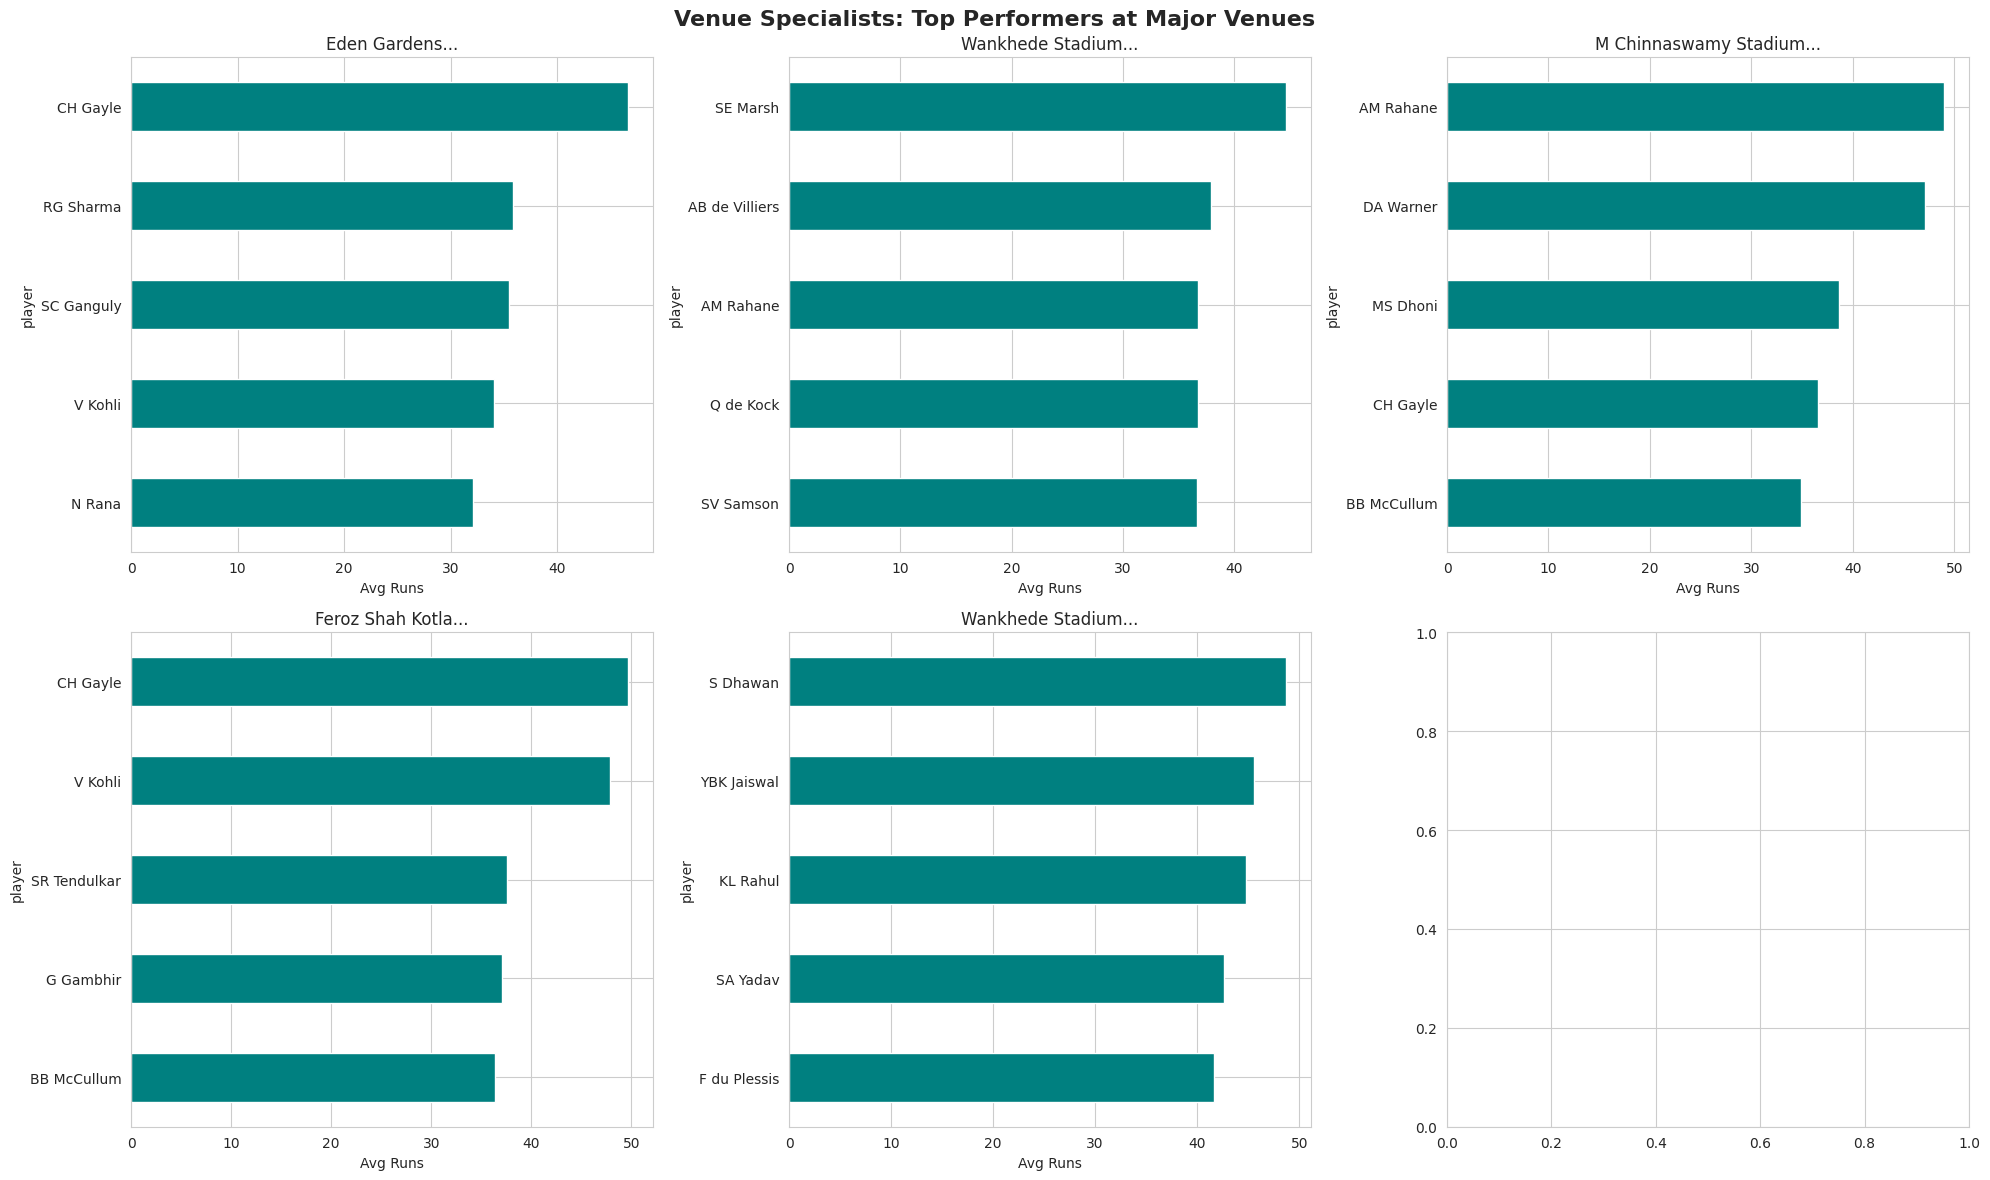

In [9]:
# ============================================================
# SECTION 8: VENUE-SPECIFIC PLAYER PERFORMANCE ***
# ============================================================
print("\n" + "="*60)
print("8. VENUE-SPECIFIC PLAYER PERFORMANCE")
print("="*60)

top_5_venues = batsman_df['venue'].value_counts().head(5).index

print("\n📍 TOP PERFORMERS AT EACH MAJOR VENUE:\n")

for venue in top_5_venues:
    print(f"\n{'='*60}")
    print(f"🏟️  {venue}")
    print(f"{'='*60}")
    
    venue_batsmen = batsman_df[batsman_df['venue'] == venue].groupby('player').agg({
        'runs': ['mean', 'count']
    }).round(2)
    venue_batsmen.columns = ['avg_runs', 'matches']
    venue_batsmen = venue_batsmen[venue_batsmen['matches'] >= 5].sort_values('avg_runs', ascending=False).head(5)
    
    print("\nTop 5 Batsmen:")
    print(venue_batsmen)
    
    venue_bowlers = bowler_df[bowler_df['venue'] == venue].groupby('player').agg({
        'wickets': ['mean', 'count']
    }).round(2)
    venue_bowlers.columns = ['avg_wickets', 'matches']
    venue_bowlers = venue_bowlers[venue_bowlers['matches'] >= 5].sort_values('avg_wickets', ascending=False).head(5)
    
    print("\nTop 5 Bowlers:")
    print(venue_bowlers)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Venue Specialists: Top Performers at Major Venues', fontsize=16, fontweight='bold')

for idx, venue in enumerate(top_5_venues[:6]):
    row = idx // 3
    col = idx % 3
    
    venue_data = batsman_df[batsman_df['venue'] == venue].groupby('player')['runs'].agg(['mean', 'count'])
    venue_data = venue_data[venue_data['count'] >= 5].sort_values('mean', ascending=False).head(5)
    
    venue_data['mean'].plot(kind='barh', ax=axes[row, col], color='teal')
    axes[row, col].set_title(f'{venue.split(",")[0][:30]}...')
    axes[row, col].set_xlabel('Avg Runs')
    axes[row, col].invert_yaxis()

plt.tight_layout()
plt.savefig('08_venue_specialists.png', dpi=300, bbox_inches='tight')
plt.show()


9. CONSISTENCY ANALYSIS

📊 Most Consistent Batsmen (Low Coefficient of Variation):
              avg_runs  std_runs  matches    cv
player                                         
Tilak Varma      29.39     19.42       51  0.66
AK Markram       26.18     19.29       55  0.74
R Dravid         26.51     19.52       82  0.74
SR Tendulkar     29.92     22.66       78  0.76
JP Duminy        27.05     20.47       75  0.76
KL Rahul         38.78     29.79      135  0.77
SPD Smith        26.83     20.65       93  0.77
RK Singh         21.55     16.54       51  0.77
F du Plessis     32.47     25.18      147  0.78
RA Jadeja        16.72     13.18      195  0.79
S Dube           24.79     19.60       75  0.79
MS Dhoni         22.57     18.03      241  0.80
SE Marsh         36.07     29.01       69  0.80
DA Warner        35.69     28.97      184  0.81
Abdul Samad      14.57     11.85       51  0.81


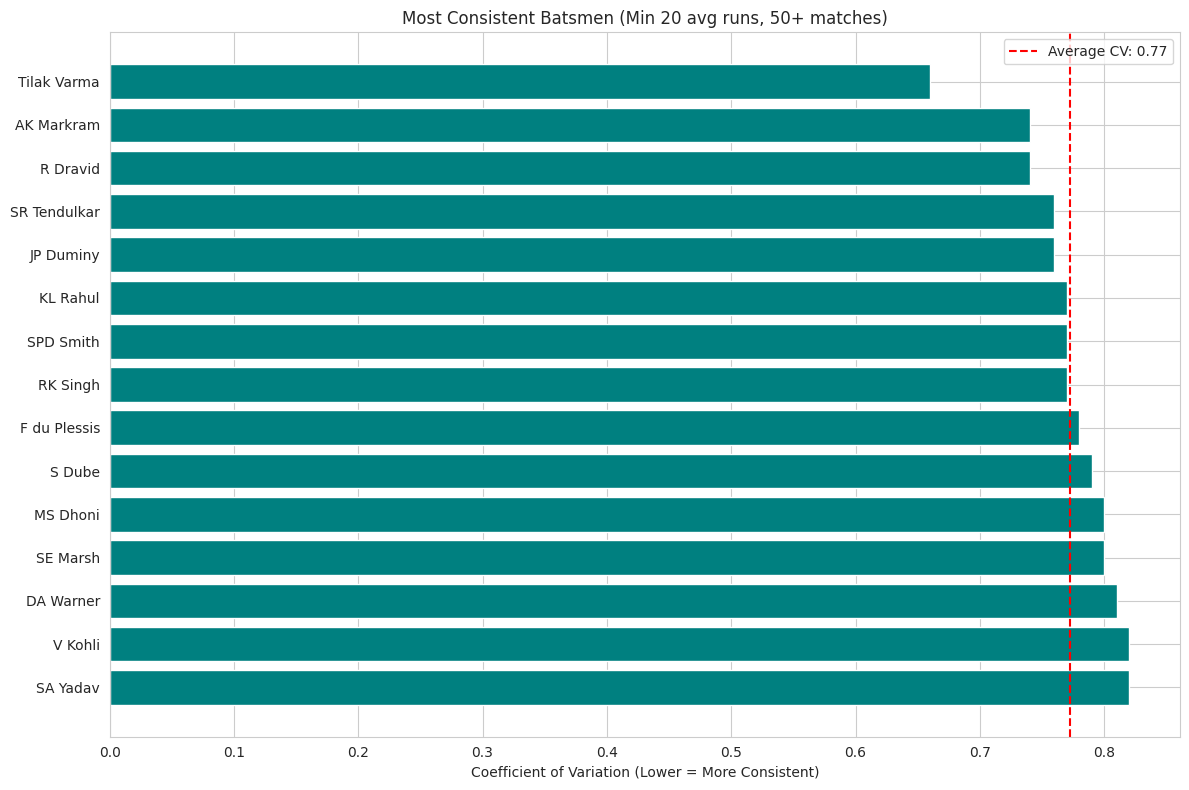


✅ EDA COMPLETE! All 9 sections analyzed.

📁 Generated Files:
   1. 01_target_distributions.png
   2. 02_venue_analysis.png
   3. 03_opponent_analysis.png
   4. 04_temporal_trends.png
   5. 05_top_performers.png
   6. 06_correlation_analysis.png
   7. 07_form_analysis.png         ← NEW!
   8. 08_venue_specialists.png     ← NEW!
   9. 09_consistency_analysis.png


In [10]:
# ============================================================
# 9. CONSISTENCY ANALYSIS (WITH VISUALIZATION)
# ============================================================
print("\n" + "="*60)
print("9. CONSISTENCY ANALYSIS")
print("="*60)

batsman_consistency = batsman_df.groupby('player').agg({
    'runs': ['mean', 'std', 'count']
}).round(2)
batsman_consistency.columns = ['avg_runs', 'std_runs', 'matches']
batsman_consistency = batsman_consistency[batsman_consistency['matches'] >= 50]
batsman_consistency['cv'] = (batsman_consistency['std_runs'] / batsman_consistency['avg_runs']).round(2)
batsman_consistency = batsman_consistency.sort_values('cv')

print(f"\n📊 Most Consistent Batsmen (Low Coefficient of Variation):")
print(batsman_consistency.head(15))

fig, ax = plt.subplots(figsize=(12, 8))
top_consistent = batsman_consistency[batsman_consistency['avg_runs'] >= 20].head(15)
ax.barh(range(len(top_consistent)), top_consistent['cv'], color='teal')
ax.set_yticks(range(len(top_consistent)))
ax.set_yticklabels(top_consistent.index)
ax.set_xlabel('Coefficient of Variation (Lower = More Consistent)')
ax.set_title('Most Consistent Batsmen (Min 20 avg runs, 50+ matches)')
ax.invert_yaxis()
ax.axvline(top_consistent['cv'].mean(), color='red', linestyle='--', label=f'Average CV: {top_consistent["cv"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('09_consistency_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("✅ EDA COMPLETE! All 9 sections analyzed.")
print("="*60)

print("\n📁 Generated Files:")
print("   1. 01_target_distributions.png")
print("   2. 02_venue_analysis.png")
print("   3. 03_opponent_analysis.png")
print("   4. 04_temporal_trends.png")
print("   5. 05_top_performers.png")
print("   6. 06_correlation_analysis.png")
print("   7. 07_form_analysis.png         ← NEW!")
print("   8. 08_venue_specialists.png     ← NEW!")
print("   9. 09_consistency_analysis.png")
